In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("recovery_dataset.csv")

In [3]:
df.head()

,phase,sleepHours,sleepQuality,energy,mood,muscleSoreness,sleepDebt,acuteLoad,chronicLoad,recoveryScore
0,Late Luteal,6.3,3,2,3,2,1.7,225.2,134.8,33.2
1,Menstrual,7.7,4,2,3,5,0.3,800.0,847.5,28.7
2,Menstrual,5.9,3,3,2,2,2.1,149.3,107.9,33.4
3,Early Luteal,7.2,4,5,4,2,0.8,194.2,220.6,58.6
4,Late Luteal,7.7,4,2,3,3,0.3,286.0,299.5,46.1


In [4]:
print(df.shape)

(20000, 10)


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   phase           20000 non-null  object 
 1   sleepHours      20000 non-null  float64
 2   sleepQuality    20000 non-null  int64  
 3   energy          20000 non-null  int64  
 4   mood            20000 non-null  int64  
 5   muscleSoreness  20000 non-null  int64  
 6   sleepDebt       20000 non-null  float64
 7   acuteLoad       20000 non-null  float64
 8   chronicLoad     20000 non-null  float64
 9   recoveryScore   20000 non-null  float64
dtypes: float64(5), int64(4), object(1)
memory usage: 1.5+ MB


,sleepHours,sleepQuality,energy,mood,muscleSoreness,sleepDebt,acuteLoad,chronicLoad,recoveryScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000
mean,6.937440,3.402150,3.054100,3.037300,2.26415,1.140495,252.877820,252.061635,47.728955
std,1.013186,0.932292,0.849594,0.939283,1.00500,0.887864,183.091153,192.355780,16.686750
min,3.500000,1.000000,1.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000
25%,6.300000,3.000000,3.000000,2.000000,2.00000,0.400000,110.700000,106.600000,36.600000
50%,6.900000,3.000000,3.000000,3.000000,2.00000,1.100000,210.900000,214.800000,48.000000
75%,7.600000,4.000000,4.000000,4.000000,3.00000,1.700000,355.000000,364.225000,59.900000
max,9.500000,5.000000,5.000000,5.000000,5.00000,4.500000,800.000000,900.000000,94.800000


In [6]:
#Phase distribution
df["phase"].value_counts(normalize=True) * 100

phase
Follicular      30.755
Early Luteal    21.380
Late Luteal     20.840
Menstrual       16.875
Ovulation       10.150
Name: proportion, dtype: float64

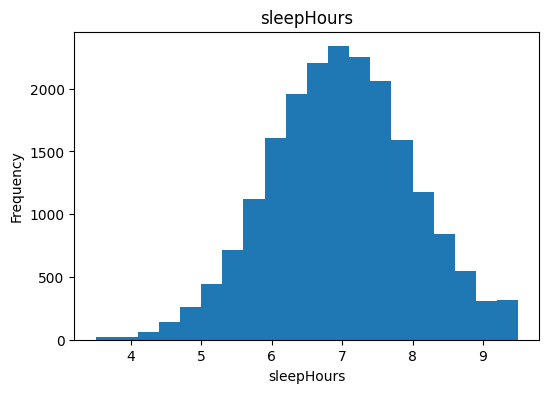

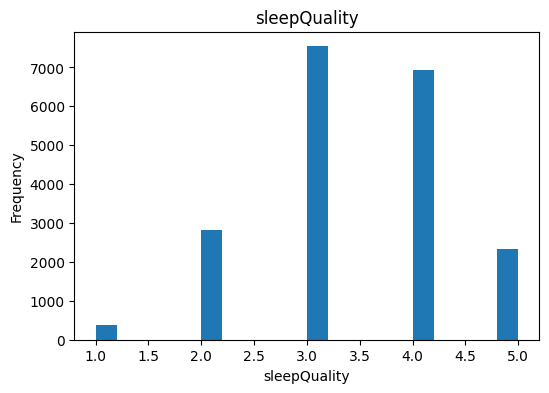

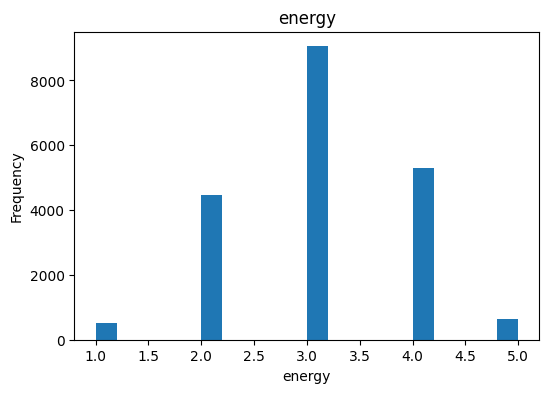

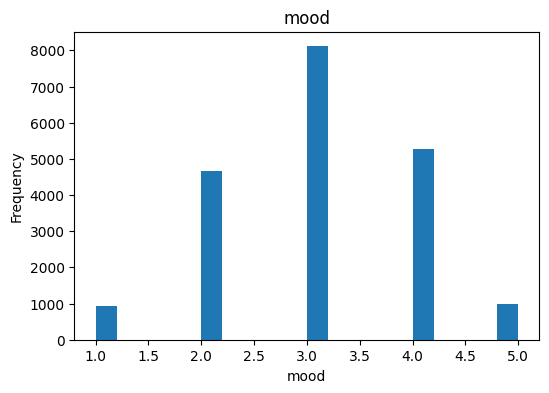

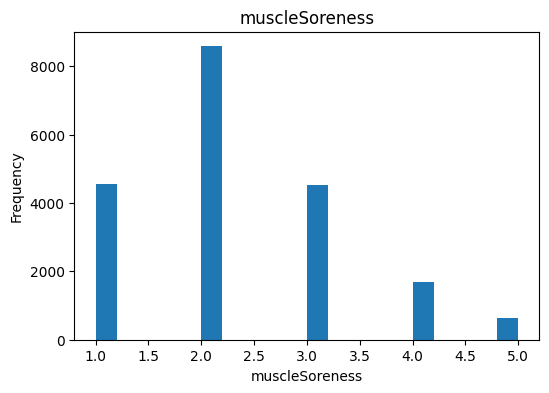

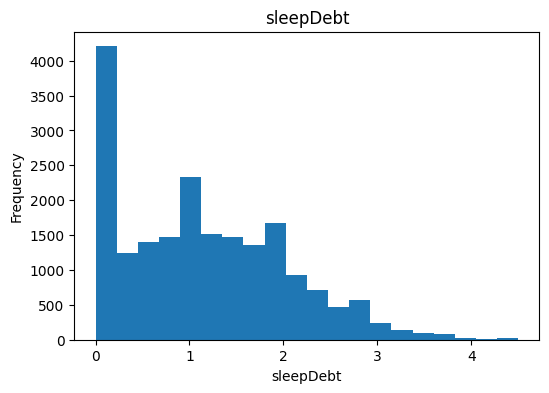

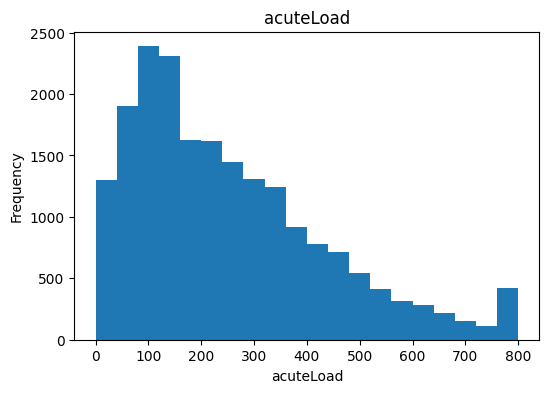

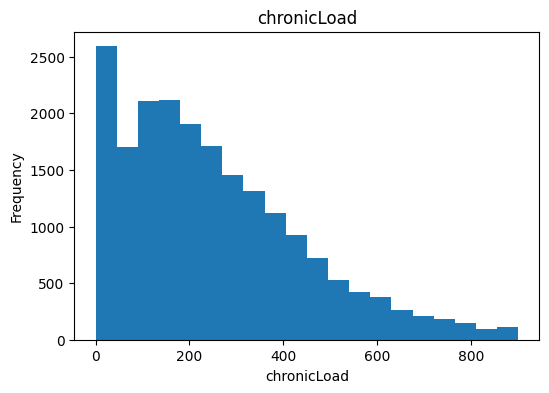

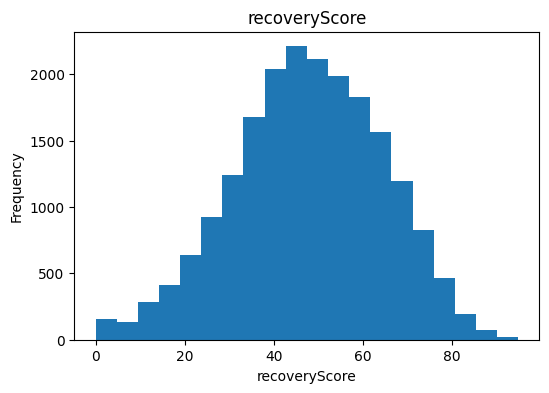

In [7]:
#Histogram
columns = [
    "sleepHours",
    "sleepQuality",
    "energy",
    "mood",
    "muscleSoreness",
    "sleepDebt",
    "acuteLoad",
    "chronicLoad",
    "recoveryScore"
]

for col in columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [8]:
#Correlation matrix
encoded = df.copy()
encoded["phase"] = encoded["phase"].astype("category").cat.codes
corr = encoded.corr(numeric_only=True)
corr

,phase,sleepHours,sleepQuality,energy,mood,muscleSoreness,sleepDebt,acuteLoad,chronicLoad,recoveryScore
phase,1.000000,-0.096386,-0.138633,-0.101667,-0.107676,-0.003776,0.094530,-0.008606,-0.008863,-0.128225
sleepHours,-0.096386,1.000000,0.617390,0.461607,0.344127,0.000663,-0.975121,0.003596,0.000810,0.735375
sleepQuality,-0.138633,0.617390,1.000000,0.551991,0.470797,0.003653,-0.613490,0.003505,0.002377,0.711476
energy,-0.101667,0.461607,0.551991,1.000000,0.647935,-0.296897,-0.455359,-0.268299,-0.252946,0.707243
mood,-0.107676,0.344127,0.470797,0.647935,1.000000,-0.115477,-0.340533,-0.105614,-0.099030,0.526254
muscleSoreness,-0.003776,0.000663,0.003653,-0.296897,-0.115477,1.000000,-0.000809,0.910315,0.850525,-0.525162
sleepDebt,0.094530,-0.975121,-0.613490,-0.455359,-0.340533,-0.000809,1.000000,-0.003311,0.000522,-0.729130
acuteLoad,-0.008606,0.003596,0.003505,-0.268299,-0.105614,0.910315,-0.003311,1.000000,0.934646,-0.512965
chronicLoad,-0.008863,0.000810,0.002377,-0.252946,-0.099030,0.850525,0.000522,0.934646,1.000000,-0.481301
recoveryScore,-0.128225,0.735375,0.711476,0.707243,0.526254,-0.525162,-0.729130,-0.512965,-0.481301,1.000000


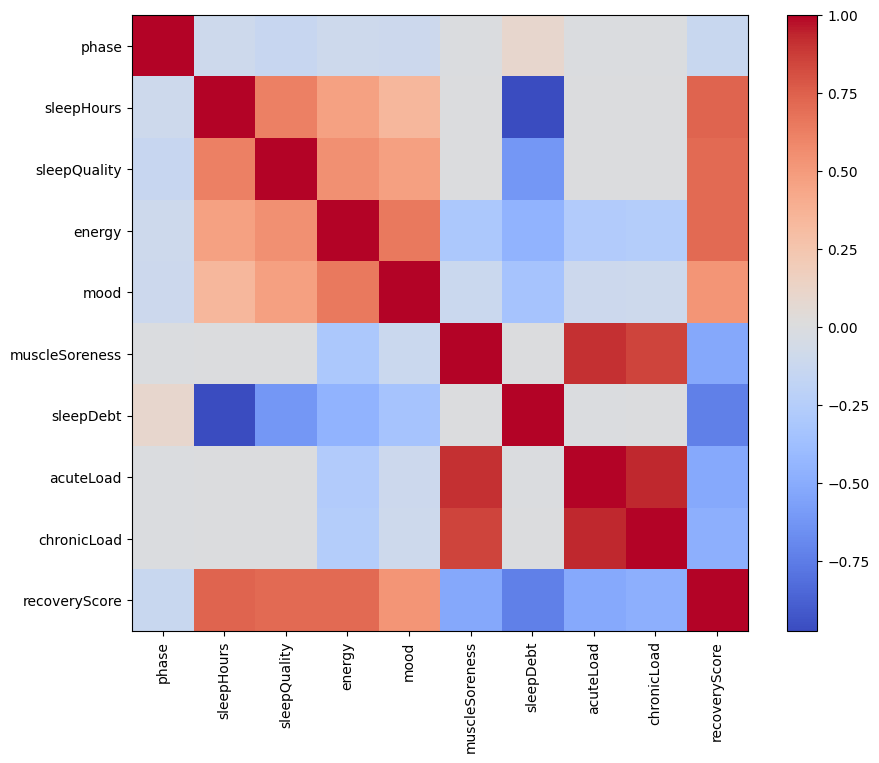

In [9]:
#Correlation Heatmap
plt.figure(figsize=(10,8))

plt.imshow(corr, cmap="coolwarm")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.show()

In [10]:
#Recovery by phase
phase_avg = df.groupby("phase")["recoveryScore"].mean()
print(phase_avg)

phase
Early Luteal    49.228508
Follicular      54.587904
Late Luteal     39.012476
Menstrual       40.222044
Ovulation       54.164729
Name: recoveryScore, dtype: float64


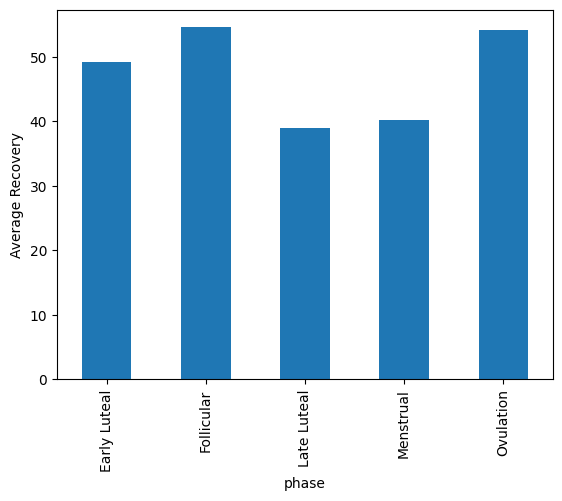

In [11]:
phase_avg.plot(kind="bar")
plt.ylabel("Average Recovery")
plt.show()

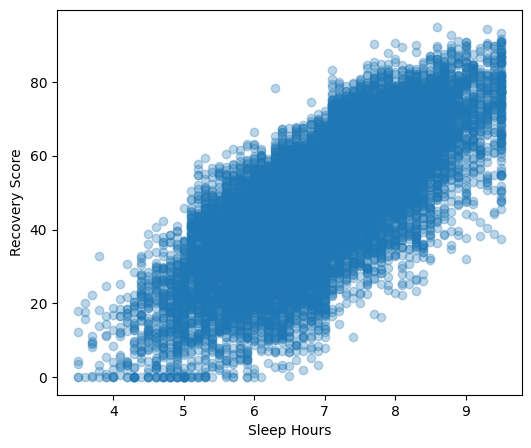

In [12]:
#Scatter plots
#sleepHours vs recoveryScore

plt.figure(figsize=(6,5))

plt.scatter(
    df["sleepHours"],
    df["recoveryScore"],
    alpha=0.3
)

plt.xlabel("Sleep Hours")
plt.ylabel("Recovery Score")

plt.show()

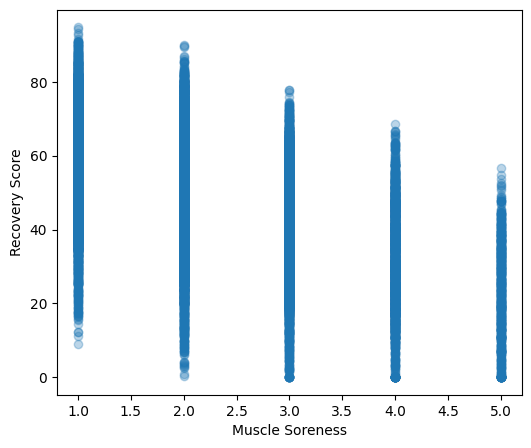

In [13]:
#muscleSoreness vs recovery score

plt.figure(figsize=(6,5))

plt.scatter(
    df["muscleSoreness"],
    df["recoveryScore"],
    alpha=0.3
)

plt.xlabel("Muscle Soreness")
plt.ylabel("Recovery Score")

plt.show()

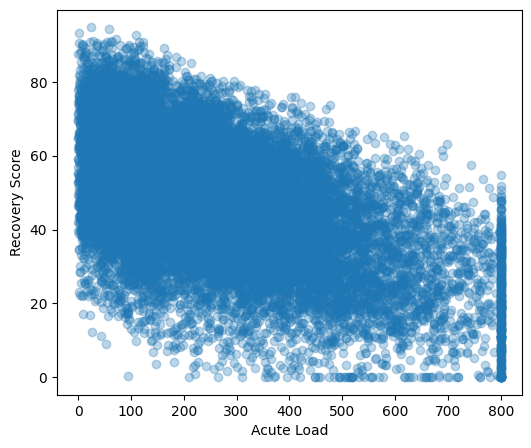

In [14]:
#Acute load vs recovery

plt.figure(figsize=(6,5))

plt.scatter(
    df["acuteLoad"],
    df["recoveryScore"],
    alpha=0.3
)

plt.xlabel("Acute Load")
plt.ylabel("Recovery Score")

plt.show()

In [15]:
#Feature importance check
corr["recoveryScore"].sort_values(ascending=False)

recoveryScore     1.000000
sleepHours        0.735375
sleepQuality      0.711476
energy            0.707243
mood              0.526254
phase            -0.128225
chronicLoad      -0.481301
acuteLoad        -0.512965
muscleSoreness   -0.525162
sleepDebt        -0.729130
Name: recoveryScore, dtype: float64